# Exercise : <sup>238</sup>Pu

<sup>238</sup>Pu is the optimal choice for “space batteries”:
<ul>
<li>For long missions, away from the Sun (beyond Mars), one cannot rely on solar panels (they would be too big)</li>
<li>Use radioactive decay as heat source</li>
<li>To keep instruments warm</li>
<li>To produce electricity (Seebeck & Peltier effect or Stirling engine)</li>
</ul>

Why <sup>238</sup>Pu?
<ul>
<li>Half-life (87.7 yr) is “order-of-magnitude” for mission life time</li>
<li>Alpha emitter (very local energy deposition)</li>
<li>Very little gamma emission (shielding can be minimal)</li>
<li>Very stable oxide (in case of accidents)</li>
</ul>

# Nuclear processes involved: 

$$
{}^{237}_{93}\mathrm{Np} + {}^{1}_{0}\mathrm{n}
\;\xrightarrow{(n,\gamma)}\;
{}^{238}_{93}\mathrm{Np}
\;\xrightarrow[\;2.099\,\text{d}\;]{\beta^-}\;
{}^{238}_{94}\mathrm{Pu}
$$

$$
\text{Fission of } {}^{237}_{93}\mathrm{Np}
$$

$$
{}^{237}_{93}\mathrm{Np}
\;\xrightarrow[\;2.144 \times 10^{6}\,\text{yr}\;]{\alpha}\;
{}^{233}_{91}\mathrm{Pa}
$$

$$
{}^{237}_{93}\mathrm{Np} + {}^{1}_{0}\mathrm{n}
\;\xrightarrow{(n, 2n)}\;
{}^{236m}_{93}\mathrm{Np}
\;\xrightarrow[\;22.5\,\text{h}\;]{\beta^-\text{ (51\%) or E.C. (49\%)}}\;
{}^{236}_{94}\mathrm{Pu}
$$

$$
{}^{239}_{93}\mathrm{Np} \text{ neutron capture and fission}
$$

$$
{}^{238}_{93}\mathrm{Np} + {}^{1}_{0}\mathrm{n}
\;\xrightarrow{(n,\gamma)}\;
{}^{239}_{93}\mathrm{Np}
\;\xrightarrow[\;2.356\,\text{d}\;]{\beta^-}\;
{}^{239}_{94}\mathrm{Pu}
$$

$$
{}^{238}_{94}\mathrm{Pu} \text{ neutron capture and fission}
$$

$$
\text{Fission of } {}^{238}_{93}\mathrm{Np}
$$

$$
{}^{236}_{93}\mathrm{Np} \text{ neutron capture and fission}
$$

$$
\text{Other Pu isotopes capture and fission}
$$

$$
\text{...Other reactions...?}
$$

# Interesting observables to track :

# Decay constants :

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
import csv

In [36]:
ISOTOPES = (
    'Pa233', 'Np236m', 'Np237', 'Np238', 'Np239',
    'Pu236', 'Pu238', 'Pu239', 'Pu240', 'Pu241', 'Pu242', 'FP'
)

INDEX = {iso: i for i, iso in enumerate(ISOTOPES)}
n = len(ISOTOPES)

In [37]:
"""
Data available on the Nuclide and Nucleus Properties Database (https://www-nds.iaea.org/relnsd/vcharthtml/VChartHTML.html (or http://wwwndc.jaea.go.jp/NuC/ , http://wwwndc.jaea.go.jp/CN14/index.html)).
"""
LN2 = np.log(2)

TRANSFORMATIONS = ('Alpha', 'BetaMinus', 'BetaPlus', 'Gamma')

HALF_LIFE_DATA = {
'Pa233':  {'Alpha': None, 'BetaMinus': 2330640, 'BetaPlus': None, 'Gamma': None},
'Np236m': {'Alpha': None, 'BetaMinus': 81000, 'BetaPlus': None, 'Gamma': None},
'Np237':  {'Alpha': 67658049289525, 'BetaMinus': None, 'BetaPlus': None, 'Gamma': None},
'Np238':  {'Alpha': None, 'BetaMinus': 181354, 'BetaPlus': None, 'Gamma': None},
'Np239':  {'Alpha': None, 'BetaMinus': 203558, 'BetaPlus': None, 'Gamma': None},
'Pu236':  {'Alpha': 90189694, 'BetaMinus': None, 'BetaPlus': None, 'Gamma': None},
'Pu238':  {'Alpha': 2767542408, 'BetaMinus': None, 'BetaPlus': None, 'Gamma': None},
'Pu239':  {'Alpha': 760837485247, 'BetaMinus': None, 'BetaPlus': None, 'Gamma': None},
'Pu240':  {'Alpha': 207044991319, 'BetaMinus': None, 'BetaPlus': None, 'Gamma': None},
'Pu241':  {'Alpha': None, 'BetaMinus': 452179192, 'BetaPlus': None, 'Gamma': None},
'Pu242':  {'Alpha': 11770733388523, 'BetaMinus': None, 'BetaPlus': None, 'Gamma': None},
'FP':     {'Alpha': None, 'BetaMinus': None, 'BetaPlus': None, 'Gamma': None}
}

def halfLife(X, Transfo):
    try:
        return HALF_LIFE_DATA[X][Transfo]
    except KeyError:
        raise ValueError(f"Invalid element ({X}) or transformation ({Transfo})")
    
def lambda_arrays():
    n = len(ISOTOPES)

    lambdas = {}

    for transfo in TRANSFORMATIONS:

        half_lives = np.array(
            [HALF_LIFE_DATA[el][transfo] for el in ISOTOPES],
            dtype=float
        )

        # Remplacer None par NaN automatiquement
        # (si None présent, dtype=float convertit en nan)

        lambda_values = np.divide(
            LN2,
            half_lives,
            out=np.zeros(n),
            where=~np.isnan(half_lives)
        )

        lambdas[transfo] = lambda_values

    return lambdas

# Cross sections : 

In [38]:
""" Data available on the Nuclide and Nucleus Properties Database (http://wwwndc.jaea.go.jp/NuC/ )."""


CROSS_SECTION_DATA = {
    'Pa233': {
        'capture':  {'thermal': 39.42,  'resonance': 835.3},
        'fission':  {'thermal': 2.502e-6, 'fast': 235.9e-3},
    },
    'Np236m': {
        'capture':  {'thermal': 121.3, 'resonance': 100.3},
        'fission':  {'thermal': 2.808e3, 'fast': 2.083},
    },
    'Np237': {
        'capture':  {'thermal': 178.1, 'resonance': 701.1},
        'fission':  {'thermal': 20.19e-3, 'fast': 1.312},
    },
    'Np238': {
        'capture':  {'thermal': 479.5, 'resonance': 201.4},
        'fission':  {'thermal': 2.202e3, 'fast': 1.441},
    },
    'Np239': {
        'capture':  {'thermal': 45.02, 'resonance': 931.8},
        'fission':  {'thermal': 28.01e-3, 'fast': 568.8e-3},
    },
    'Pu236': {
        'capture':  {'thermal': 27.56, 'resonance': 248.0},
        'fission':  {'thermal': 140.0, 'fast': 2.330},
    },
    'Pu238': {
        'capture':  {'thermal': 412.8, 'resonance': 146.2},
        'fission':  {'thermal': 17.77, 'fast': 1.934},
    },
    'Pu239': {
        'capture':  {'thermal': 271.5, 'resonance': 179.7},
        'fission':  {'thermal': 747.4, 'fast': 1.781},
    },
    'Pu240': {
        'capture':  {'thermal': 289.3, 'resonance': 8.502e3},
        'fission':  {'thermal': 36.21e-3, 'fast': 1.304},
    },
    'Pu241': {
        'capture':  {'thermal': 363.1, 'resonance': 180.4},
        'fission':  {'thermal': 1.012e3, 'fast': 1.606},
    },
    'Pu242': {
        'capture':  {'thermal': 19.88, 'resonance': 1.126e3},
        'fission':  {'thermal': 2.436e-3, 'fast': 1.125},
    },
    'FP':     {
        'capture':  {'thermal': 0.0, 'resonance': 0.0},
        'fission':  {'thermal': 0.0, 'fast': 0.0},
    }
}

def crossSection(X, reaction, energy):
    try:
        return CROSS_SECTION_DATA[X][reaction][energy]
    except KeyError:
        raise ValueError(f"Invalid input: {X}, {reaction}, {energy}")
    
ELEMENTS_XS = tuple(CROSS_SECTION_DATA.keys())
INDEX = {el: i for i, el in enumerate(ELEMENTS_XS)}

def cross_section_arrays():

    n = len(ELEMENTS_XS)

    sigma = {
        'capture_thermal': np.zeros(n),
        'capture_resonance': np.zeros(n),
        'fission_thermal': np.zeros(n),
        'fission_fast': np.zeros(n),
    }

    for i, el in enumerate(ELEMENTS_XS):

        sigma['capture_thermal'][i] = CROSS_SECTION_DATA[el]['capture']['thermal']
        sigma['capture_resonance'][i] = CROSS_SECTION_DATA[el]['capture']['resonance']
        sigma['fission_thermal'][i] = CROSS_SECTION_DATA[el]['fission']['thermal']
        sigma['fission_fast'][i] = CROSS_SECTION_DATA[el]['fission']['fast']

    return sigma

# Equations :

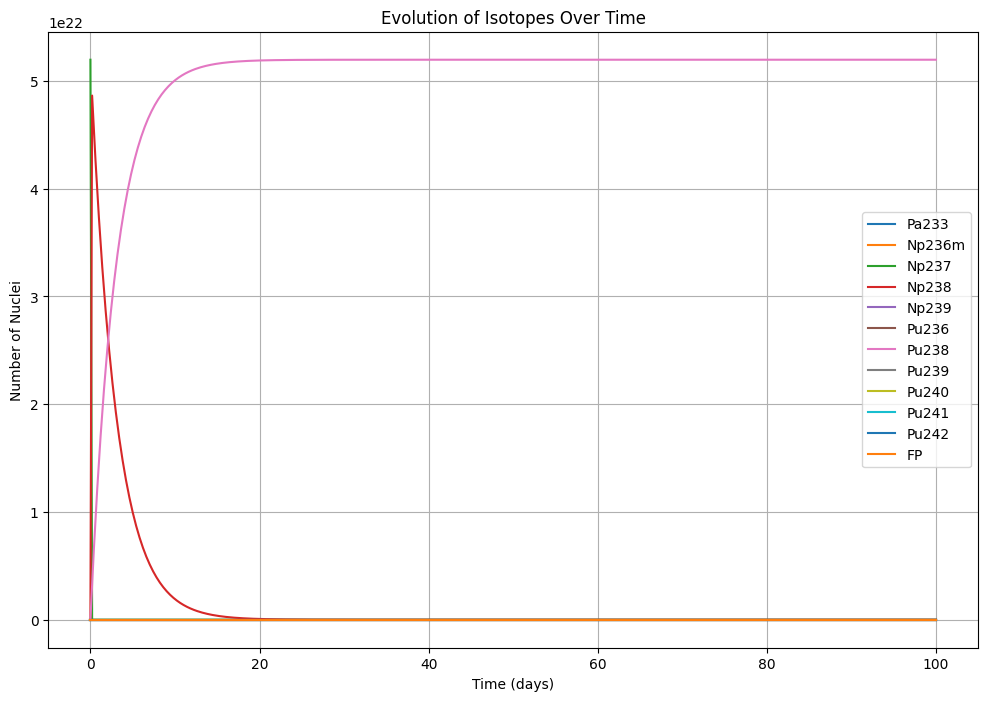

In [39]:
Flux_Tot = 1e14 # [n/cm^2/s]

Flux_Th = Flux_Tot * 0.85 # [n/cm^2/s]

Flux_EpiTh = Flux_Tot * 0.15 # [n/cm^2/s] # Still need to understand how to conscider fast fission  with this type of flux?

density_Np237 = 20.45 * 6.022e23 / 237 # [#/cm^3]

N_0 = np.array([0, 0, density_Np237, 0, 0, 0, 0, 0, 0, 0, 0, 0])

isotopes = [
    'Pa233', 'Np236m', 'Np237', 'Np238', 'Np239',
    'Pu236', 'Pu238', 'Pu239', 'Pu240', 'Pu241', 'Pu242', 'FP'
]

index = {iso: i for i, iso in enumerate(isotopes)}
n = len(isotopes)

lambdas = lambda_arrays()
sigma = cross_section_arrays()

rates = {
    'capture_thermal': Flux_Th * sigma['capture_thermal'],
    'capture_resonance': Flux_EpiTh * sigma['capture_resonance'],
    'fission_thermal': Flux_Th * sigma['fission_thermal'],
    'fission_fast': Flux_EpiTh * sigma['fission_fast'], # Still need to understand how to conscider fast fission  with this type of flux???
}

transitions = [

    # Beta decay
    ('Np238', 'Pu238', lambdas['BetaMinus'][INDEX['Np238']]),

    # Capture thermique
    ('Np237', 'Np238', rates['capture_thermal'][INDEX['Np237']]),

    # Capture résonance
    ('Np237', 'Np238', rates['capture_resonance'][INDEX['Np237']]),

    # Fission
    ('Pu239', 'FP', rates['fission_thermal'][INDEX['Pu239']]),
    ('Pu239', 'FP', rates['fission_fast'][INDEX['Pu239']]),
]

def build_A(transitions):

    A = np.zeros((n, n))

    for parent, daughter, rate in transitions:

        i = INDEX[parent]
        A[i, i] -= rate

        if daughter is not None:
            j = INDEX[daughter]
            A[j, i] += rate

    return A

A = build_A(transitions)

t_max = 100 * 24 * 3600  # 10 jours
time = np.linspace(0, t_max, 500)

N_time = np.array([expm(A * ti) @ N_0 for ti in time])

plt.figure(figsize=(12, 8))
for i, iso in enumerate(isotopes):
    plt.plot(time / (24 * 3600), N_time[:, i], label=iso)
plt.xlabel('Time (days)')
plt.ylabel('Number of Nuclei')
plt.title('Evolution of Isotopes Over Time')
plt.legend()
plt.grid()
plt.show()